Figure 1 Draft

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import datetime

In [4]:
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")

In [5]:
CARIACO.columns

Index(['Unnamed: 0', 'tauoc', 'sst', 'sp', 'u10', 'v10', 'lsm', 'si10', 'ewss',
       'e', 'ro', 'tp', 'mtpr', 'time_month', 'O2_umol_kg', 'O2_ml_L',
       'NO3_UDO', 'PO4_UDO', 'SiO4_UDO', 'NH4_USF', 'NO2_USF', 'NO3_NO2_USF',
       'NO3_USF', 'PO4_USF', 'SiO4_USF', 'NO3_merged', 'PO4_merged',
       'SiO4_merged', 'pH_corrected', 'Salinity_bottles', 'Temperature',
       'Sigma_t', 'PrimaryProductivity', 'Chlorophyll', 'Phaeopigments',
       'source', 'Pras', 'Lut', 'Fuco', 'Perid', 'Allo', 'But_fuco',
       'Hex_fuco', 'Zea', 'Tot_Chl_b', 'DP', 'Tot_Chl_a', 'TChl', 'Chl_c1c2',
       'Chl_c3', 'DP2', 'micro', 'nano', 'pico', 'Mesh200', 'Mesh500',
       'Isotherm_21', 'MLD', 'SST', 'ui', 'upwelling', 'euphotic_depth'],
      dtype='object')

In [6]:
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")

CARIACO.ui = CARIACO.ui.astype('category').cat.reorder_categories(['relaxed', 'weak','moderate', 'strong'])

CARIACO.upwelling = CARIACO.upwelling.astype('category').cat.reorder_categories(['relaxed', 'upwelling'])

In [7]:
Fish = pd.read_csv("../DATA/processed/fisheries.csv")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
Fish.columns

Index(['Unnamed: 0', 'year', 'sardinelandings', 'date'], dtype='object')

In [8]:

cluster1_mask = (CARIACO.date.dt.date>datetime.date(1996, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2003, 12, 31)) | \
                 (CARIACO.date.dt.date>datetime.date(2014, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2016, 12, 31))

cluster2_mask = (CARIACO.date.dt.date>datetime.date(2004, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2013, 12, 31))

CARIACO["cluster"] = 'none'
CARIACO.loc[cluster1_mask, "cluster"] = 'cluster 1'
CARIACO.loc[cluster2_mask, "cluster"] = 'cluster 2'

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean
import datetime

# --- Helper Function 1: Geometric Mean Calculation ---

def safe_gmean(series):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# --- Helper Function 2: Data Processing (Resampling and Clustering) ---

def process_data_for_timelines(CARIACO_raw, Fish_raw):
    """
    Cleans, resamples, calculates G-Means, and sets up dates for plotting.
    """
    
    # 1. Process Data
    CARIACO_raw['date'] = pd.to_datetime(CARIACO_raw.time_month, format="%m-%Y")
    Fish_raw['date'] = pd.to_datetime(Fish_raw.year, format="%Y")
    CARIACO_raw['Zoo_Total'] = CARIACO_raw['Mesh200'] + CARIACO_raw['Mesh500']
    Fish_raw['sardinelandings_M'] = Fish_raw['sardinelandings'] / 1_000_000

    # 2. Calculate Yearly Geometric Means
    yearly_cariaco = CARIACO_raw.resample('YE', on='date').agg({
        'Isotherm_21': safe_gmean,
        'Chlorophyll': safe_gmean,
        'Zoo_Total': safe_gmean
    }).reset_index()

    # Create 'plot_date' at the middle of the year (July 1st)
    yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)
    Fish_raw['plot_date'] = Fish_raw['date'] + pd.DateOffset(months=6)
    
    # 3. Define and Assign Clusters (Needed for background shading)
    c1_ranges = [
        (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
        (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
    ]
    c2_ranges = [
        (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
    ]
    
    # We only need the ranges here, not the full DF assignment, but keeping them
    # defined for the shading logic below.
    
    return yearly_cariaco, Fish_raw, c1_ranges, c2_ranges

# --- Main Plotting Function ---

def draw_timeline_stack(fig, subplot_spec, yearly_cariaco, Fish, c1_ranges, c2_ranges):
    """
    Draws the 4-row timeline stack (Iso, Chl, Zoo, Fish) into the 
    provided subplot_spec (a specific region of the parent figure).
    """
    
    # --- Plotting Style Setup (Taken from your original script) ---
    plt.rcParams['font.size'] = 10
    plt.rcParams['axes.titlesize'] = 12
    plt.rcParams['axes.labelsize'] = 10
    plt.rcParams['xtick.labelsize'] = 9
    plt.rcParams['ytick.labelsize'] = 9
    plt.rcParams['legend.fontsize'] = 9
    
    # 1. Create a nested GridSpec inside the provided slot (4 rows, 1 column)
    gs_inner = gridspec.GridSpecFromSubplotSpec(4, 1, subplot_spec=subplot_spec, hspace=0)

    # 2. Create the 4 axes
    axA = fig.add_subplot(gs_inner[0, 0])
    axB = fig.add_subplot(gs_inner[1, 0], sharex=axA)
    axC = fig.add_subplot(gs_inner[2, 0], sharex=axA)
    axD = fig.add_subplot(gs_inner[3, 0], sharex=axA)
    timeline_axes = [axA, axB, axC, axD]

    # 3. Background Shading (Regimes)
    shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}

    for ax in timeline_axes:
        for start, end in c1_ranges:
            ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
        for start, end in c2_ranges:
            ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

    # 4. Plot Data (Using your labels and styling)
    plot_start = datetime.date(1996, 1, 1)
    plot_end = datetime.date(2017, 1, 1)

    # Row 1: Isotherm
    axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
    axA.set_ylabel("21°C Iso\n(m)")
    axA.set_title("A: Timeline (1996-2017)", fontsize=12, loc='left')
    
    # Row 2: Chlorophyll
    axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
    axB.set_ylabel("Chl a\n($mg/m^3$)")
    
    # Row 3: Zooplankton
    axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
    axC.set_ylabel("Zoo\n(mg/m³)")
    
    # Row 4: Fisheries
    axD.plot(Fish.plot_date, Fish.sardinelandings_M, color='black', marker='o', ms=4, lw=1.5)
    axD.set_ylabel("Fisheries\n(M tonnes)")
    axD.set_xlabel("Year")
    

    # 5. Formatting (Hidden X-labels, Tick Settings)
    for i, ax in enumerate(timeline_axes):
        ax.grid(True, color='lightgrey', which='major')
        ax.grid(True, lw=0.2, color='lightgrey', which="minor")
        ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) 
        ax.get_xaxis().set_minor_locator(mdates.YearLocator())
        ax.tick_params(top=False, right=True, direction="in")
        ax.set_xlim(plot_start, plot_end)
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        
        # Hide x-labels and top spine for inner panels
        if i < 3:
            plt.setp(ax.get_xticklabels(), visible=False)
            ax.spines['bottom'].set_visible(False)
        ax.spines['top'].set_visible(False)
            
    fig.align_ylabels(timeline_axes)
    
    return timeline_axes # Returns the axes list for external reference if needed

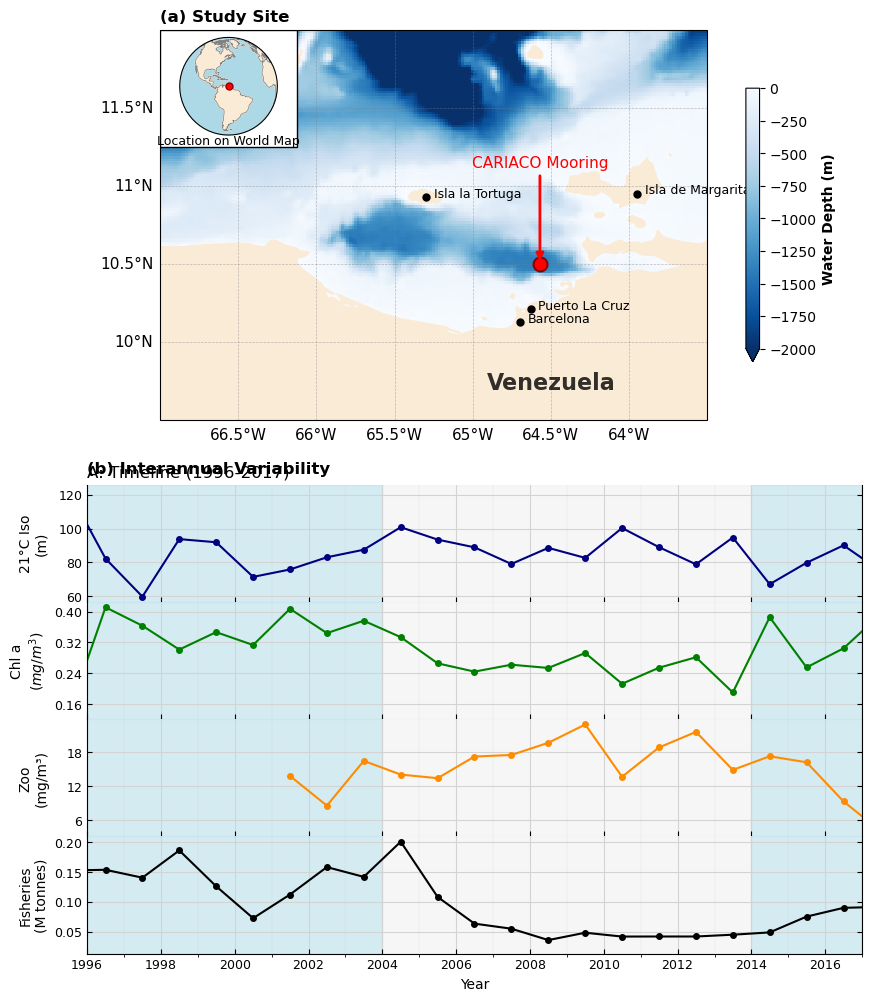

In [20]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec

# Import your modules
# 'cariaco_map_module' is the script I generated in the previous response
# 'ts_timelines' is the script above
import map_script as cariaco_map_module

# Assuming you have your dataframes 'yearly_cariaco' and 'Fish' loaded 
# from your data processing block...

# --- 1. Setup the Figure Canvas ---
fig = plt.figure(figsize=(10, 12))

# Create an Outer Grid: 2 Rows, 1 Column
# height_ratios=[1, 1.2] gives the time series slightly more vertical space 
# because it has 4 stacked plots.
gs_outer = gridspec.GridSpec(2, 1, height_ratios=[1, 1.2], hspace=0.15)

# --- 2. TOP PANEL: Map ---
# We add the subplot using the Map's required projection
ax_map = fig.add_subplot(gs_outer[0], projection=ccrs.PlateCarree())

# Call your Map Function
GRID_REGION = [-67.0, -63.5, 9.5, 12.0]
bathymetry_grid = cariaco_map_module.load_bathymetry(GRID_REGION)
# Note: Ensure you have 'bathymetry_grid' loaded as per previous instructions
cariaco_map_module.draw_cariaco_map_with_inset(ax=ax_map, fig=fig, grid=bathymetry_grid)
ax_map.set_title("(a) Study Site", loc='left', fontsize=12, weight='bold')


# --- 3. BOTTOM PANEL: Time Series Stack ---
# We pass the grid slot 'gs_outer[1]' to the function.
# The function will build the 4 internal rows inside that slot.
yearly_cariaco, Fish, c1_ranges, c2_ranges = process_data_for_timelines(
    CARIACO, Fish
)
draw_timeline_stack(fig, gs_outer[1], yearly_cariaco, Fish, c1_ranges, c2_ranges)

# Add a title for the whole bottom block (optional)
# We can anchor it to the top axis of the stack or place it using text
# Here is a simple way to put it on the figure relative to the grid:
# (You might need to tweak the 'y' coordinate slightly)
fig.text(0.125, 0.51, "(b) Interannual Variability", fontsize=12, weight='bold')


# --- 4. Save ---
#plt.savefig("Figure1_Map_and_Timeline.pdf", dpi=300, bbox_inches='tight')
plt.show()